# Máquinas Térmicas - Lección 12
## Ensayo de Motores (Bancos de Prueba y Métricas de Desempeño)

**Autor:** Camilo Bayona
**Fecha:** 23/09/25

*La Lección 11 dio $T_{motor}(\omega)$ — el motor solo, en el papel. Esta lección responde dos preguntas prácticas: **¿cómo se mide eso de verdad en un banco de pruebas?** y **¿por qué el motor se queda quieto exactamente en un régimen cuando le imponemos una carga?** La segunda pregunta tiene una respuesta de sistema dinámico: $J\dot\omega = T_{motor}(\omega) - T_{carga}(\omega)$ converge a donde ambos pares se igualan — y el banco de pruebas es, ni más ni menos, la máquina que fija $T_{carga}(\omega)$ y lee el punto de equilibrio resultante.*

### Objetivos de aprendizaje

Al finalizar esta lección, el estudiante será capaz de:

- Identificar los **elementos** de una **banca de ensayo de motores** y su función.
- Medir y calcular **potencia al freno**, **flujo de combustible**, **consumo específico al freno (CEC)** y **eficiencia térmica al freno**.
- Estimar el **flujo teórico de aire** para motores **2T** y **4T** a partir de la geometría y el régimen.
- Interpretar y utilizar la **presión media efectiva (PME)** (indicada y al freno) para comparar motores.
- Diferenciar **potencia indicada (Pi)**, **potencia al freno (Pf)** y **pérdidas por fricción (Pfricc)** en el balance mecánico.
- Explicar **por qué** el conjunto motor-freno converge a un régimen estacionario, y cuándo ese régimen es estable.

In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy"], check=True)

In [2]:
# === Setup =================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch, Wedge, Polygon, FancyBboxPatch
from scipy.optimize import brentq
from scipy.integrate import odeint
from ipywidgets import (interact, interactive_output, FloatSlider, IntSlider,
                        Dropdown, Checkbox, Play, HBox, VBox, jslink)
from IPython.display import display

Rgas = 287.0
cv0, cp0, k0 = 718.0, 1005.0, 1005.0/718.0

# Paleta del proyecto (misma que Lecciones 7-11)
COL = {"aire": "#2a78d6", "abierta": "#1baf7a", "cerrada": "#8a8a86", "perdida": "#e34948",
       "combustion": "#eb6834", "diesel": "#4a3aa7", "agua": "#1baf7a", "aceite": "#eda100",
       "metal": "#c3c2b7", "tinta": "#3a3a38", "freno": "#4a3aa7"}

print("Setup OK")

Setup OK


## 1. Banco de ensayo de motores: componentes y disposición

Si se desea conocer el comportamiento de un motor de combustión interna se recurre a instalar un banco de trabajo en el cual se emplea un freno hidraulico, un dinamometro o un freno prony. Los elementos que necesitan son los siguientes:

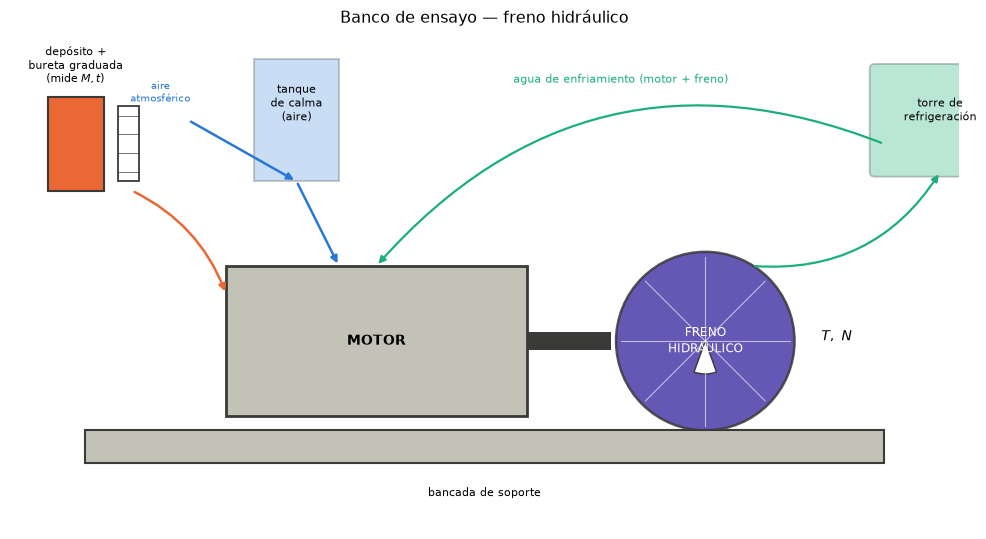

In [3]:
# Diagrama propio del banco de ensayo — reemplaza dos imágenes del original (una con etiquetas
# cortadas por generación IA, otra un escaneo clásico que se redibuja en el lenguaje del proyecto)
def dibujar_banco(ax, tipo_freno="hidráulico"):
    # motor
    ax.add_patch(Rectangle((2.0, 1.0), 3.2, 1.6, fc=COL["metal"], ec=COL["tinta"], lw=2))
    ax.text(3.6, 1.8, "MOTOR", ha="center", va="center", fontsize=10, fontweight="bold")
    # eje de acople
    ax.add_patch(Rectangle((5.2, 1.7), 0.9, 0.2, fc=COL["tinta"], ec="none"))
    # freno / dinamómetro
    if tipo_freno == "hidráulico":
        ax.add_patch(Circle((7.1, 1.8), 0.95, fc=COL["freno"], alpha=0.85, ec=COL["tinta"], lw=1.8))
        ax.text(7.1, 1.8, "FRENO\nHIDRÁULICO", ha="center", va="center", fontsize=8.5, color="white")
        for a0 in np.linspace(0, 2*np.pi, 8, endpoint=False):
            ax.plot([7.1, 7.1+0.9*np.cos(a0)], [1.8, 1.8+0.9*np.sin(a0)], color="white", lw=0.8, alpha=0.6)
    elif tipo_freno == "friccional (Prony)":
        ax.add_patch(Circle((7.1, 1.8), 0.7, fc=COL["metal"], ec=COL["tinta"], lw=1.8))
        ax.add_patch(Rectangle((6.6, 1.55), 1.9, 0.5, fc="none", ec=COL["tinta"], lw=2))
        ax.text(7.75, 1.05, "brazo + peso\n(mide F)", ha="center", fontsize=8)
        ax.text(7.1, 1.8, "TAMBOR\nPRONY", ha="center", va="center", fontsize=8, fontweight="bold")
    else:
        ax.add_patch(Circle((7.1, 1.8), 0.95, fc=COL["diesel"], alpha=0.85, ec=COL["tinta"], lw=1.8))
        ax.text(7.1, 1.8, "FRENO\nELECTRO-\nMAGNÉTICO", ha="center", va="center", fontsize=7.5, color="white")
        ax.plot([7.1-0.5, 7.1+0.5], [2.9, 2.9], color=COL["combustion"], lw=1.5)
        ax.text(7.1, 3.05, "bobina de campo (I)", ha="center", fontsize=7.5, color=COL["combustion"])
    ax.add_patch(Wedge((7.1, 1.8), 0.35, 250, 290, fc="white", ec=COL["tinta"], lw=1))
    ax.text(8.5, 1.8, "$T,\\ N$", fontsize=10, ha="center")

    # combustible
    ax.add_patch(Rectangle((0.1, 3.4), 0.6, 1.0, fc=COL["combustion"], ec=COL["tinta"], lw=1.5))
    ax.add_patch(Rectangle((0.85, 3.5), 0.22, 0.8, fc="none", ec=COL["tinta"], lw=1.3))
    for yy in [3.6, 3.8, 4.0, 4.2]:
        ax.plot([0.85, 1.07], [yy, yy], color=COL["tinta"], lw=0.5)
    ax.annotate("", xy=(2.0, 2.3), xytext=(1.0, 3.4),
               arrowprops=dict(arrowstyle="-|>", color=COL["combustion"], lw=1.8,
                               connectionstyle="arc3,rad=-0.2"))
    ax.text(0.4, 4.55, "depósito +\nbureta graduada\n(mide $M,t$)", ha="center", fontsize=7.8)

    # aire (tanque de calma)
    ax.add_patch(Rectangle((2.3, 3.5), 0.9, 1.3, fc=COL["aire"], alpha=0.25, ec=COL["tinta"], lw=1.5))
    ax.text(2.75, 4.15, "tanque\nde calma\n(aire)", ha="center", fontsize=7.8)
    ax.annotate("", xy=(3.2, 2.6), xytext=(2.75, 3.5),
               arrowprops=dict(arrowstyle="-|>", color=COL["aire"], lw=1.8))
    ax.annotate("", xy=(2.75, 3.5), xytext=(1.6, 4.15),
               arrowprops=dict(arrowstyle="-|>", color=COL["aire"], lw=1.8))
    ax.text(1.3, 4.35, "aire\natmosférico", ha="center", fontsize=7.5, color=COL["aire"])

    # circuito de agua
    ax.add_patch(FancyBboxPatch((8.9, 3.6), 1.4, 1.1, boxstyle="round,pad=0.05",
                                fc=COL["agua"], alpha=0.3, ec=COL["tinta"], lw=1.3))
    ax.text(9.6, 4.15, "torre de\nrefrigeración", ha="center", fontsize=7.8)
    ax.annotate("", xy=(9.6, 3.6), xytext=(7.6, 2.6),
               arrowprops=dict(arrowstyle="-|>", color=COL["agua"], lw=1.6,
                               connectionstyle="arc3,rad=0.3"))
    ax.annotate("", xy=(3.6, 2.6), xytext=(9.0, 3.9),
               arrowprops=dict(arrowstyle="-|>", color=COL["agua"], lw=1.6,
                               connectionstyle="arc3,rad=0.35"))
    ax.text(6.2, 4.55, "agua de enfriamiento (motor + freno)", ha="center", fontsize=7.8, color=COL["agua"])

    # bancada
    ax.add_patch(Rectangle((0.5, 0.5), 8.5, 0.35, fc=COL["metal"], ec=COL["tinta"], lw=1.5))
    ax.text(4.75, 0.15, "bancada de soporte", ha="center", fontsize=8)
    ax.set_xlim(-0.3, 9.8); ax.set_ylim(-0.2, 5.1)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"Banco de ensayo — freno {tipo_freno}", fontsize=11.5)

fig, ax = plt.subplots(figsize=(10, 6))
dibujar_banco(ax, "hidráulico")
plt.tight_layout(); plt.show()

**Elementos de una banca de ensayo de motores**

1. **Bancada de soporte** para motor y freno.
2. **Freno hidráulico** o dispositivo de medición del **par**.
3. **Sistema de medición de la velocidad** del cigüeñal.
4. **Depósito de combustible graduado** para medir el consumo.
5. **Recipiente cerrado de gran volumen** para medir el **consumo de aire**.
6. **Intercambiador de calor** para enfriar el agua refrigerante del bloque y realizar el **balance térmico** de este circuito.

> **Nota:** La instrumentación debe incluir transductores de **par**, **rpm**, **temperaturas** (aceite, refrigerante, gases), **presiones** (admisión/escape), **caudalímetros** (combustible/aire/agua) y un sistema de adquisición de datos.

In [4]:
# WIDGET 1 — tipo de freno del banco (comparación visual; la física de cada uno se explora en el
# Widget 6, más adelante, junto con la dinámica de convergencia)
def widget1_banco(tipo_freno="hidráulico"):
    fig, ax = plt.subplots(figsize=(10, 6))
    dibujar_banco(ax, tipo_freno)
    plt.tight_layout(); plt.show()

interact(widget1_banco,
         tipo_freno=Dropdown(options=["hidráulico", "friccional (Prony)", "electromagnético"],
                             description="freno"));

interactive(children=(Dropdown(description='freno', options=('hidráulico', 'friccional (Prony)', 'electromagné…

## 2. Datos típicos aportados por los bancos de ensayo

| Nomenclatura | Descripcion | Unidades |
|---------|------|-----------|
| $N$ | Velocidad rotacional del motor | rpm |
| $M$ | Consumo de combustible durante el tiempo del ensayo | kg |
| $t$ | Tiempo transcurrido | s |
| $T$ | Par del motor al freno, a velocidad constante $N$ debida a una determinada apertura del acelerador | N·m |
| $\dot{V}$ | Flujo volumétrico del aire | m³/s |

Como condiciones iniciales se requiere conocer el poder calorífico del combustible, normalmente utilizando el poder calorífico inferior PCI (kJ/kg).

## 3. Potencia al freno $(P_{\text{freno}})$ o al eje

El primer valor que se requiere calcular es la potencia al freno, es decir la **potencia que aplica el freno** para **mantener la velocidad rotacional del motor constante**; esta magnitud viene relacionada al par $T$ por la velocidad rotacional.

Esta potencia se determina multiplicando el par $T$ por la velocidad angular $\omega$ en radianes por segundo:

$$P_{\text{freno}} = T\cdot\omega = T\cdot\frac{2\pi N}{60}$$

donde $T$ [N·m] es el par medido en el freno y $N$ [rpm] la velocidad del cigüeñal. Nótese que $P_{\text{freno}}$ solo tiene sentido en **régimen estacionario** ($\dot\omega=0$): es exactamente el par que el freno debe oponer para que el sistema motor-freno de la §7.5 (más abajo) esté en equilibrio a esa $N$.

## 4. Flujo de combustible y CEC al freno

El flujo de combustible se calcula mediante (en kg/s):

$$\dot{m}_c = \frac{M}{t}$$

donde $M$ [kg] es la masa de combustible consumida durante el ensayo y $t$ [s] el tiempo transcurrido — típicamente medido con una **bureta graduada** y un cronómetro: se dispara el cronómetro cuando el nivel pasa una marca y se detiene en otra marca de volumen conocido.

### Consumo específico de combustible al freno

El **consumo específico de combustible al freno** (CEC, o *BSFC* — *brake specific fuel consumption*) es una medida indirecta del rendimiento del motor y se determina haciendo la razón entre el flujo de combustible y la potencia al freno:

$$cec = \frac{\dot{m}_c}{P_{\text{freno}}} \qquad [\text{kg/J}]$$

En la práctica de ingeniería el CEC casi siempre se reporta en **g/kWh** (gramos de combustible por kilowatt-hora de trabajo entregado):

$$\text{BSFC}\;[\text{g/kWh}] = cec\;[\text{kg/J}] \times 3.6\times10^{9}$$

*(motores de gasolina bien afinados: BSFC $\approx$ 270–320 g/kWh; diésel: $\approx$ 200–260 g/kWh — cuanto más bajo, mejor, ya que se necesita menos combustible por unidad de trabajo entregado.)*

In [5]:
# WIDGET 2 — medición de combustible: bureta graduada + cronómetro (Play), con P_freno, ṁc, CEC y BSFC
def widget2_combustible(N=3000.0, T=150.0, M_kg=0.5, t_total=120.0, i=50):
    P_freno = T*2*np.pi*N/60                          # W
    frac = i/99.0
    t_actual = frac*t_total
    m_consumida = frac*M_kg
    mc_dot = M_kg/t_total                              # kg/s (promedio del ensayo completo)
    cec = mc_dot/P_freno                                # kg/J
    bsfc = cec*3.6e9                                    # g/kWh

    fig = plt.figure(figsize=(10.5, 5))
    ax0 = fig.add_axes([0.06, 0.1, 0.22, 0.82])
    ax1 = fig.add_axes([0.42, 0.12, 0.55, 0.76])

    # bureta graduada
    nivel = 1.0-frac
    ax0.add_patch(Rectangle((0.3, 0.1), 0.6, 3.4, fc="none", ec=COL["tinta"], lw=2))
    ax0.add_patch(Rectangle((0.32, 0.12), 0.56, 3.36*nivel, fc=COL["combustion"], alpha=0.75, ec="none"))
    for frac_marca in np.linspace(0, 1, 6):
        yy = 0.12+3.36*frac_marca
        ax0.plot([0.3, 0.42], [yy, yy], color=COL["tinta"], lw=1)
    ax0.annotate("", xy=(0.3, 0.12+3.36*nivel), xytext=(-0.15, 0.12+3.36*nivel),
                arrowprops=dict(arrowstyle="-|>", color=COL["perdida"], lw=1.6))
    ax0.text(-0.2, 0.12+3.36*nivel, f"{m_consumida*1000:.0f} g\nconsumidos", ha="right", va="center",
             fontsize=8.5, color=COL["perdida"])
    ax0.set_xlim(-1.1, 1.0); ax0.set_ylim(0, 3.7); ax0.axis("off")
    ax0.set_title(f"t = {t_actual:.0f} s / {t_total:.0f} s", fontsize=10)

    ts = np.linspace(0, t_total, 100)
    ax1.plot(ts, M_kg*1000*(1-ts/t_total), color=COL["combustion"], lw=2.2)
    ax1.plot(t_actual, m_consumida*1000, "o", ms=10, color=COL["perdida"], mec="white", mew=1.3)
    ax1.axhline(0, color=COL["metal"], lw=0.8, ls=":")
    ax1.set_xlabel("tiempo [s]"); ax1.set_ylabel("combustible restante en la bureta [g]")
    ax1.set_title(f"$P_{{freno}}$={P_freno/1000:.2f} kW | $\\dot m_c$={mc_dot*1000:.3f} g/s | "
                 f"CEC={cec:.2e} kg/J | BSFC={bsfc:.0f} g/kWh", fontsize=10.5)
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.show()

play2 = Play(value=50, min=0, max=99, step=2, interval=60)
i_sl2 = IntSlider(50, min=0, max=99, description="i (tiempo)")
jslink((play2, "value"), (i_sl2, "value"))
N_sl2 = FloatSlider(3000, min=800, max=6000, step=100, description="N [rpm]")
T_sl2 = FloatSlider(150, min=20, max=300, step=5, description="T [N·m]")
M_sl2 = FloatSlider(0.5, min=0.1, max=2.0, step=0.05, description="M [kg]")
t_sl2 = FloatSlider(120, min=30, max=300, step=10, description="t [s]")
out2 = interactive_output(widget2_combustible, {"N": N_sl2, "T": T_sl2, "M_kg": M_sl2,
                                                 "t_total": t_sl2, "i": i_sl2})
display(VBox([HBox([play2, i_sl2]), HBox([N_sl2, T_sl2, M_sl2, t_sl2]), out2]))

## 5. Eficiencia térmica al freno

Para determinar la eficiencia térmica al freno, se utiliza el consumo específico multiplicado por el poder calorífico inferior (PCI):

$$\eta_{\text{freno}} = (cec\cdot\text{PCI})^{-1}$$

donde $\text{PCI}$ [J/kg] es el poder calorífico inferior del combustible. Esta es exactamente la **eficiencia térmica real** del motor completo (combustión + mecánica) — el mismo concepto de $\eta_{th}$ de la Lección 11, pero medido de punta a punta en el banco en vez de calculado a partir del ciclo ideal.

## 6. Flujo teórico de aire $(\dot{V}_{\text{teo}})$

El flujo teórico de aire se determina mediante el producto del desplazamiento volumétrico multiplicado por el número de ciclos de aspiración por segundo. Con $n_R$ el número de revoluciones de cigüeñal por ciclo termodinámico ($n_R=1$ en 2T, $n_R=2$ en 4T):

$$\dot{V}_{\text{teo}} = N_c\cdot\frac{\pi d^2}{4}\cdot L\cdot\frac{N}{60\,n_R}$$

Para motores de **dos tiempos** ($n_R=1$):

$$\dot{V}_{\text{teo}} = N_c\cdot\frac{\pi d^2}{4}\cdot L\cdot\frac{N}{60}$$

Para motores de **cuatro tiempos** ($n_R=2$):

$$\dot{V}_{\text{teo}} = N_c\cdot\frac{\pi d^2}{4}\cdot L\cdot\frac{N}{120}$$

donde $N_c$ es el **número de cilindros**, $d$ [m] el diámetro y $L$ [m] la carrera.

> **Nota de edición:** la versión anterior de esta lección escribía estas fórmulas con $N_c$ dividido adicionalmente entre 2 (4T) o 4 (2T) — una división espuria que no aparece en ninguna referencia estándar (Heywood, Pulkrabek — Lección 11) ni coincide con el propio código de cálculo de la lección original, que ya usaba la forma correcta de arriba. Corregido aquí para que prosa y código concuerden.

> **Rendimiento volumétrico $(\eta_v)$**: el flujo **real** de aire suele ser $\dot{V}_{\text{real}}\approx\eta_v\,\dot{V}_{\text{teo}}$, con $\eta_v$ entre **0.75–1.10** según régimen, sobrealimentación y diseño de admisión — el mismo $\eta_v(N)$ de la Lección 11 que da forma a la curva de par (§7.5 de esta lección).

### ¿Por qué hace falta un tanque de calma para medir el aire?

Un motor no "respira" de forma continua: cada cilindro **aspira en pulsos** durante su propia carrera de admisión. Un medidor de orificio o Venturi necesita un $\Delta P$ **estable** para dar una lectura confiable — imposible si el flujo pulsa violentamente. El **recipiente cerrado de gran volumen** (tanque de calma) actúa como un amortiguador: su volumen es tan grande comparado con el desplazado por cilindro que absorbe los pulsos y entrega, aguas abajo (hacia el medidor), un flujo prácticamente constante igual al **promedio** — exactamente $\dot V_{teo}\cdot\eta_v$.

In [6]:
# WIDGET 3 — medición de aire: por qué hace falta el tanque de calma (pulsos vs. flujo suavizado)
# y el caudalímetro de orificio que se lee río abajo del tanque
def widget3_aire(N=3000.0, Ncyl=4, d=0.086, L=0.086, eta_v_val=0.85, Cd=0.62, area_orificio_cm2=8.0):
    Vs = np.pi/4*d**2*L
    Vdot_teo = Ncyl*Vs*N/120.0
    Vdot_real = eta_v_val*Vdot_teo
    rho_aire = 1.18                                     # kg/m3, aire ambiente

    T_ciclo = 120.0/N
    t = np.linspace(0, 4*T_ciclo, 2000)
    T_pulso = T_ciclo/Ncyl
    fase = (t % T_pulso)/T_pulso
    pico = Vdot_real*np.pi/2
    q_inst = pico*np.sin(np.pi*fase)                    # flujo instantáneo aguas arriba del tanque
    q_suave = np.full_like(t, Vdot_real)                # flujo aguas abajo del tanque (suavizado)

    DeltaP = 0.5*rho_aire*(Vdot_real/(Cd*area_orificio_cm2*1e-4))**2   # Pa, ecuación de orificio
    Vdot_medido = Cd*area_orificio_cm2*1e-4*np.sqrt(2*DeltaP/rho_aire)

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.9))
    ax0.plot(t*1000, q_inst*1000, color=COL["aire"], lw=1.6, alpha=0.75, label="antes del tanque (pulsante)")
    ax0.plot(t*1000, q_suave*1000, color=COL["perdida"], lw=2.4, label="después del tanque (suavizado)")
    ax0.set_xlabel("tiempo [ms]"); ax0.set_ylabel("flujo instantáneo [L/s]")
    ax0.set_title(f"{Ncyl} cilindro(s) a {N:.0f} rpm — el tanque promedia los pulsos")
    ax0.legend(fontsize=9); ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)

    ax1.bar(["$\\dot V_{teo}$", "$\\dot V_{real}=\\eta_v\\dot V_{teo}$", "$\\dot V$ medido\n(orificio)"],
            [Vdot_teo*1000, Vdot_real*1000, Vdot_medido*1000],
            color=[COL["metal"], COL["aire"], COL["perdida"]])
    err = abs(Vdot_medido-Vdot_real)/Vdot_real*100
    ax1.set_ylabel("$\\dot V$ [L/s]")
    ax1.set_title(f"$\\Delta P$ en el orificio = {DeltaP:.0f} Pa | error medición vs. real = {err:.1f} %",
                 fontsize=10.5)
    ax1.grid(axis="y", alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(widget3_aire,
         N=FloatSlider(3000, min=800, max=6000, step=100, description="N [rpm]"),
         Ncyl=IntSlider(4, min=1, max=8, description="N cilindros"),
         d=FloatSlider(0.086, min=0.06, max=0.12, step=0.002, description="d [m]"),
         L=FloatSlider(0.086, min=0.06, max=0.12, step=0.002, description="L [m]"),
         eta_v_val=FloatSlider(0.85, min=0.6, max=1.1, step=0.02, description="η_v"),
         Cd=FloatSlider(0.62, min=0.5, max=0.85, step=0.01, description="Cd orificio"),
         area_orificio_cm2=FloatSlider(8.0, min=2, max=20, step=0.5, description="área [cm²]"));

interactive(children=(FloatSlider(value=3000.0, description='N [rpm]', max=6000.0, min=800.0, step=100.0), Int…

**Explora con el widget:** sube el número de cilindros y observa cómo, incluso *antes* del tanque, la superposición de varios pulsos ya suaviza algo el flujo (más cilindros = admisiones más entrelazadas) — pero el tanque sigue siendo indispensable para llegar a una lectura verdaderamente estable en el orificio. El $\dot V$ medido coincide con $\dot V_{real}=\eta_v\dot V_{teo}$ por construcción (el widget calcula primero $\dot V_{real}$ y luego el $\Delta P$ que *produciría* esa lectura) — así se ve exactamente cómo el instrumento traduce una presión diferencial en un caudal reportado.

## 7. Presión Media Efectiva (PME)

La presión media efectiva de un motor es la presión promedio que actúa sobre el pistón durante el ciclo de trabajo del motor. Representa la presión que, si se aplicara de manera uniforme sobre toda la superficie del pistón, produciría la misma cantidad de trabajo que el motor produce en condiciones reales de funcionamiento.

La presión media efectiva es una herramienta que permite comparar el rendimiento de diferentes motores y para evaluar mejoras en la eficiencia y la potencia. Se calcula mediante la integración de las presiones instantáneas durante el ciclo de trabajo y se expresa generalmente en unidades de presión, como bares o psi. Una presión media efectiva más alta indica un motor más eficiente y potente, mientras que una presión más baja puede indicar pérdidas en el rendimiento del motor.

### 7.1 Presión media efectiva indicada

El valor de la presión media efectiva si viene dado por el diagrama $P$-$V$ se llama presión **media efectiva indicada**, la cual está definida como el trabajo neto del ciclo dividido por el volumen desplazado — hace referencia a las lecturas realizadas *dentro* del cilindro para varias posiciones angulares del cigüeñal del motor:

$$P_{mei} = \frac{W_{neto}}{V_s}$$

donde $W_{neto}$ [J] es el área encerrada por el diagrama $P$-$V$ (Lección 11) y $V_s$ [m³] el volumen desplazado. Para este caso podemos calcular la presión media efectiva indicada reutilizando el modelo del ciclo Otto de la Lección 11:

Trabajo neto del ciclo: 1084.5 J
Volumen desplazado Vs: 1178.1 cm³
PME indicada: 920.6 kPa = 9.21 bar


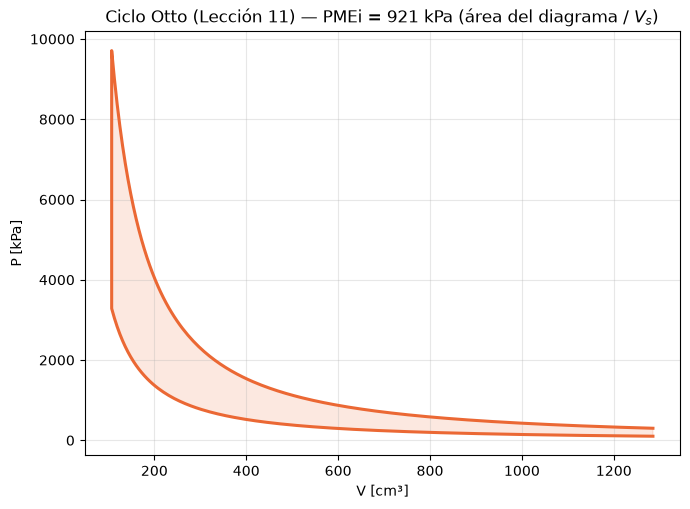

In [7]:
# Ciclo Otto (mismo modelo validado en la Lección 11) — reutilizado aquí con el cilindro de esta
# lección (d=0.1 m, L=0.15 m, r=12) para calcular PMEi a partir del área del diagrama P-V
def ciclo_otto_pv(r=12.0, T1=288.0, T3=2300.0, P1=101325.0, n=200):
    k = k0
    V_BDC = np.pi/4*0.10**2*0.15                        # Vs de esta lección (d=0.1, L=0.15)
    V_TDC = V_BDC/(r-1)
    V1 = V_TDC + V_BDC
    T2 = T1*r**(k-1); P2 = P1*r**k
    P3 = P2*(T3/T2)                                       # combustión a V=cte
    T4 = T3*(1/r)**(k-1); P4 = P3*(1/r)**k
    Vcomp = np.linspace(V1, V_TDC, n); Pcomp = P1*(V1/Vcomp)**k
    Vexp = np.linspace(V_TDC, V1, n); Pexp = P3*(V_TDC/Vexp)**k
    V = np.concatenate([Vcomp, Vexp])
    P = np.concatenate([Pcomp, Pexp])
    return dict(V=V, P=P, Vs=V_BDC, V_TDC=V_TDC, V1=V1, T2=T2, T3=T3, T4=T4, P2=P2, P3=P3, P4=P4)

c = ciclo_otto_pv()
# W_neto = área encerrada por el lazo P-V = integral de línea cerrada (trapecios, cerrando el lazo)
W_neto = abs(np.trapezoid(np.concatenate([c["P"], [c["P"][0]]]), np.concatenate([c["V"], [c["V"][0]]])))
Pmei = W_neto/c["Vs"]
print(f"Trabajo neto del ciclo: {W_neto:.1f} J")
print(f"Volumen desplazado Vs: {c['Vs']*1e6:.1f} cm³")
print(f"PME indicada: {Pmei/1e3:.1f} kPa = {Pmei/1e5:.2f} bar")

fig, ax = plt.subplots(figsize=(7, 5.2))
ax.plot(c["V"]*1e6, c["P"]/1e3, color=COL["combustion"], lw=2.2)
ax.fill(c["V"]*1e6, c["P"]/1e3, color=COL["combustion"], alpha=0.15)
ax.set_xlabel("V [cm³]"); ax.set_ylabel("P [kPa]")
ax.set_title(f"Ciclo Otto (Lección 11) — PMEi = {Pmei/1e3:.0f} kPa (área del diagrama / $V_s$)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 7.2 Presión media efectiva al freno

Si la presión es medida sobre la potencia en el eje del motor, o la potencia al freno, se denomina **presión media efectiva al freno** ($P_{mef}$), la cual está relacionada con la $P_{mei}$ mediante la **eficiencia mecánica** $\eta_m$ (la fracción de la potencia indicada que sobrevive a la fricción y los auxiliares antes de llegar al eje):

$$P_{mef} = P_{mei}\cdot\eta_m$$

> **Nota de edición:** la versión anterior de esta lección escribía $P_{mef}=P_{mei}\cdot\eta_{th,Otto}$ (la eficiencia **térmica**) en una línea, y en la siguiente hablaba de "$\eta_m$, la eficiencia mecánica" como si fuera el mismo símbolo. Son conceptos distintos: $\eta_{th}$ compara *energía química del combustible* contra *trabajo del ciclo* (ya fijada por $r$ y $T_3$, Lección 11); $\eta_m$ compara *trabajo indicado* contra *trabajo al freno* — es puramente mecánica (fricción de anillos/cojinetes, bombeo de aceite, accesorios) y **no depende** de la combustión. La relación correcta usa $\eta_m$.

**Potencias.** Con estos dos valores se puede estimar la potencia indicada ($P_i$) y la potencia de freno ($P_f$), valores que permiten entender mejor el comportamiento del motor:

$$P_i = P_{mei}\cdot V_s\cdot N_c\cdot\frac{N}{120}, \qquad P_f = P_{mef}\cdot V_s\cdot N_c\cdot\frac{N}{120} = \eta_m\, P_i$$

con la relación de orden ($P_i>P_f>0$, y $P_{fricc}=P_i-P_f$).

In [8]:
# WIDGET 4 — PMEi/PMEf y potencias indicada/al freno, con eficiencia mecánica como control independiente
def widget4_pme(r=12.0, T3=2300.0, eta_m_val=0.82, N=3000.0, Ncyl=1):
    c = ciclo_otto_pv(r=r, T3=T3)
    W_neto = abs(np.trapezoid(np.concatenate([c["P"], [c["P"][0]]]), np.concatenate([c["V"], [c["V"][0]]])))
    Pmei = W_neto/c["Vs"]
    Pmef = Pmei*eta_m_val
    Pi = Pmei*c["Vs"]*Ncyl*N/120
    Pf = Pmef*c["Vs"]*Ncyl*N/120
    Pfricc = Pi-Pf

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
    ax0.plot(c["V"]*1e6, c["P"]/1e3, color=COL["combustion"], lw=2.2)
    ax0.fill(c["V"]*1e6, c["P"]/1e3, color=COL["combustion"], alpha=0.15)
    ax0.set_xlabel("V [cm³]"); ax0.set_ylabel("P [kPa]")
    ax0.set_title(f"PMEi={Pmei/1e3:.0f} kPa | PMEf={Pmef/1e3:.0f} kPa (η_m={eta_m_val:.0%})")
    ax0.grid(alpha=0.3); ax0.spines[["top", "right"]].set_visible(False)

    ax1.barh(["$P_i$ (indicada)", "$P_f$ (al freno)", "$P_{fricc}$ (perdida)"],
            [Pi/1000, Pf/1000, Pfricc/1000],
            color=[COL["metal"], COL["aire"], COL["perdida"]])
    for yi, val in enumerate([Pi/1000, Pf/1000, Pfricc/1000]):
        ax1.text(val, yi, f" {val:.2f} kW", va="center", fontsize=10)
    ax1.set_xlabel("Potencia [kW]"); ax1.set_title(f"{Ncyl} cilindro(s) @ {N:.0f} rpm — $P_i>P_f>0$")
    ax1.grid(axis="x", alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(widget4_pme,
         r=FloatSlider(12.0, min=6, max=20, step=0.5, description="r"),
         T3=FloatSlider(2300, min=1800, max=2800, step=50, description="T₃ [K]"),
         eta_m_val=FloatSlider(0.82, min=0.6, max=0.95, step=0.01, description="η_m"),
         N=FloatSlider(3000, min=800, max=6000, step=100, description="N [rpm]"),
         Ncyl=IntSlider(1, min=1, max=8, description="N cilindros"));

interactive(children=(FloatSlider(value=12.0, description='r', max=20.0, min=6.0, step=0.5), FloatSlider(value…

## 7.5 Por qué el motor se estabiliza en un régimen: un sistema dinámico

Todo lo anterior asumió $N$ **constante**. Pero, ¿por qué el conjunto motor-freno se queda quieto en un $N$ concreto cuando fijamos el acelerador y el control del freno? La respuesta es la segunda ley de Newton para rotación:

$$J\,\dot\omega = T_{motor}(\omega) - T_{carga}(\omega)$$

donde $J$ [kg·m²] es la inercia rotacional combinada (motor + volante + rotor del freno), $T_{motor}(\omega)$ es la curva de par **propia** del motor (fijada por la apertura del acelerador — Lección 11: más aire y combustible admitidos, más $P_{mei}$) y $T_{carga}(\omega)$ es el par que opone el freno. Un **régimen estacionario** ($\dot\omega=0$) ocurre donde ambas curvas se cruzan: $T_{motor}(N^*)=T_{carga}(N^*)$.

No basta con cruzarse: el punto debe ser **estable**. Si perturbamos $N$ ligeramente por encima de $N^*$, necesitamos que $T_{carga}$ crezca más rápido que $T_{motor}$ (par neto negativo, frena de vuelta); si lo perturbamos por debajo, necesitamos par neto positivo (acelera de vuelta). La condición es:

$$\left.\frac{d}{dN}\Big(T_{motor}-T_{carga}\Big)\right|_{N^*} < 0 \qquad\text{(equilibrio estable)}$$

La curva de par del motor no es plana: sube desde ralentí, alcanza un máximo (limitado por $\eta_v(N)$, la misma eficiencia volumétrica de la §6) y luego cae porque la fricción mecánica $\eta_m(N)$ crece con $N$ — exactamente $T_{motor}(N)=P_{mef}(N)\cdot V_s\cdot N_c/(4\pi)$ con $P_{mef}=P_{mei}\cdot\eta_v(N)\cdot\eta_m(N)$.

In [9]:
# Curva de par propia del motor T_motor(N) — sube por η_v(N), cae por η_m(N) decreciente (fricción)
def eta_v_curva(N, Npeak=3200.0, ancho=2200.0, vmax=0.92):
    return vmax*np.exp(-((N-Npeak)/ancho)**2)

def eta_m_curva(N, k=6e-5):
    return np.clip(0.92-k*N, 0.55, 0.95)

def T_motor_curva(N, PMEi_max=1200e3, Vs=4.98e-4, Ncyl=4, acelerador=1.0):
    PMEi = PMEi_max*acelerador*(eta_v_curva(N)/eta_v_curva(3200.0))
    PMEf = PMEi*eta_m_curva(N)
    return PMEf*Vs*Ncyl/(4*np.pi)

# Tres tipos de freno — el mismo par expresado como función de la velocidad angular ω=2πN/60
def T_carga_curva(N, tipo="hidráulico", control=1.0):
    omega = 2*np.pi*N/60
    if tipo == "hidráulico":
        return 0.00035*control*omega**2              # arrastre turbulento: T∝ω² (nivel de agua/válvula)
    elif tipo == "friccional (Prony)":
        return 80.0*control*np.ones_like(np.asarray(N, dtype=float))  # Coulomb: T≈cte (fuerza de frenado)
    else:
        return 0.28*control*omega                     # corrientes de Foucault: T∝ω (corriente de campo)

print("T_motor_curva() y T_carga_curva() listos")

T_motor_curva() y T_carga_curva() listos


In [10]:
# WIDGET 5 (flagship) — dinámica rotacional: convergencia (o estancamiento) al régimen estacionario
Bore_dyn, Stroke_dyn, Ncyl_dyn = 0.086, 0.086, 4
Vs_dyn = np.pi/4*Bore_dyn**2*Stroke_dyn
J_dyn = 0.35   # kg·m² — inercia combinada motor+volante+freno, orden de magnitud típico

def equilibrios(tipo, control, acelerador):
    Ngrid = np.linspace(300, 6800, 3000)
    neto = T_motor_curva(Ngrid, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador) - \
           T_carga_curva(Ngrid, tipo, control)
    cambios = np.where(np.diff(np.sign(neto)) != 0)[0]
    raices = []
    for idx in cambios:
        r = brentq(lambda N: T_motor_curva(N, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador)
                   - T_carga_curva(N, tipo, control), Ngrid[idx], Ngrid[idx+1])
        deriv = ((T_motor_curva(r+5, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador)
                 - T_carga_curva(r+5, tipo, control)) -
                (T_motor_curva(r-5, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador)
                 - T_carga_curva(r-5, tipo, control)))/10
        raices.append((r, deriv < 0))
    return raices

def widget5_dinamica(tipo="hidráulico", control=1.0, acelerador=1.0, N0=1000.0, i=60):
    dt, n_steps = 0.05, 200
    Ns = np.empty(n_steps); N = N0
    for j in range(n_steps):
        Ns[j] = N
        w = 2*np.pi*N/60
        Tm = T_motor_curva(N, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador)
        Tc = T_carga_curva(N, tipo, control)
        w = max(w + (Tm-Tc)/J_dyn*dt, 0.0)
        N = w*60/(2*np.pi)
    raices = equilibrios(tipo, control, acelerador)

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12.5, 5.2))
    Ngrid = np.linspace(300, 6800, 300)
    ax0.plot(Ngrid, T_motor_curva(Ngrid, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador),
             color=COL["combustion"], lw=2.4, label="$T_{motor}(N)$")
    ax0.plot(Ngrid, T_carga_curva(Ngrid, tipo, control), color=COL["freno"], lw=2.4,
             label=f"$T_{{carga}}(N)$ — {tipo}")
    for r, estable in raices:
        ax0.plot(r, T_carga_curva(np.array([r]), tipo, control)[0], "o", ms=11,
                color=(COL["abierta"] if estable else COL["perdida"]), mec="white", mew=1.5, zorder=5)
    Ni = Ns[i]
    ax0.plot(Ni, T_motor_curva(Ni, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador), "D", ms=9,
             color=COL["tinta"], mec="white", mew=1.2, zorder=6)
    ax0.set_xlabel("N [rpm]"); ax0.set_ylabel("T [N·m]"); ax0.set_ylim(0, None)
    txt_est = ", ".join(f"{r:.0f} rpm ({'estable' if e else 'inestable'})" for r, e in raices) or "ninguno en el rango"
    ax0.set_title(f"equilibrios: {txt_est}", fontsize=10)
    ax0.legend(fontsize=9); ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)

    ax1.plot(np.arange(i+1)*dt, Ns[:i+1], color=COL["tinta"], lw=2.2)
    ax1.plot(i*dt, Ns[i], "o", ms=9, color=COL["perdida"], mec="white", mew=1.2)
    for r, estable in raices:
        ax1.axhline(r, color=(COL["abierta"] if estable else COL["perdida"]), lw=1, ls=":")
    ax1.set_xlim(0, n_steps*dt); ax1.set_ylim(0, 6800)
    ax1.set_xlabel("tiempo [s]"); ax1.set_ylabel("N(t) [rpm]")
    estado = "estancado (caló)" if Ns[i] < 50 and i > 20 else f"N = {Ns[i]:.0f} rpm"
    ax1.set_title(f"trayectoria desde $N_0$={N0:.0f} rpm — {estado}")
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

play5 = Play(value=60, min=0, max=199, step=2, interval=60)
i_sl5 = IntSlider(60, min=0, max=199, description="i (tiempo)")
jslink((play5, "value"), (i_sl5, "value"))
tipo_dd5 = Dropdown(options=["hidráulico", "friccional (Prony)", "electromagnético"], description="freno")
control_sl5 = FloatSlider(1.0, min=0.2, max=2.0, step=0.05, description="control carga")
acel_sl5 = FloatSlider(1.0, min=0.3, max=1.0, step=0.05, description="acelerador")
N0_sl5 = FloatSlider(1000.0, min=300, max=6000, step=50, description="N₀ [rpm]")
out5 = interactive_output(widget5_dinamica, {"tipo": tipo_dd5, "control": control_sl5,
                                             "acelerador": acel_sl5, "N0": N0_sl5, "i": i_sl5})
display(VBox([HBox([play5, i_sl5]), HBox([tipo_dd5, control_sl5, acel_sl5, N0_sl5]), out5]))

**Explora con el widget:** con el freno **friccional (Prony)**, el par de carga es prácticamente constante — y eso produce **dos** equilibrios: uno inestable (rojo) a bajas RPM y uno estable (verde) a RPM altas. Arranca con $N_0$ **por debajo** del punto rojo y el motor **se cala** (converge a $N=0$, no a un régimen); arranca por **encima** y sube hasta el punto verde. Con el freno **hidráulico** o el **electromagnético**, el par de carga crece con $N$ lo suficientemente rápido como para dejar un único equilibrio estable, sin importar dónde arranques — por eso son los preferidos para barrer curvas completas de un motor sin riesgo de que se cale a mitad de la prueba.

### Tres formas de imponer $T_{carga}(\omega)$

| Freno | Fenómeno físico | $T_{carga}$ | Control | Ventaja / limitación |
|---|---|---|---|---|
| **Hidráulico** | arrastre turbulento de un rotor en una carcasa llena de agua | $\propto\omega^2$ | nivel de agua / válvula de purga | alta capacidad de potencia, robusto; respuesta lenta (llenar/vaciar agua) |
| **Friccional (Prony)** | fricción de Coulomb (casi independiente de la velocidad relativa) | $\approx$ cte | fuerza de frenado (peso/resorte) | simple, histórico; se desgasta, poca potencia, y —como vimos arriba— puede dar equilibrios **inestables** |
| **Electromagnético (Foucault)** | corrientes inducidas en un disco que gira en un campo magnético | $\propto\omega$ | corriente de campo | control **electrónico preciso** y de respuesta rápida — domina en bancos modernos |

El agua o el campo magnético no "desaparecen" la energía: la **convierten en calor**, que hay que evacuar — de ahí la torre de refrigeración del freno en el diagrama de la §1.

In [11]:
# WIDGET 6 — comparador de los tres frenos sobre la MISMA curva de motor (vista de conjunto)
def widget6_comparador(acelerador=1.0, control=1.0):
    Ngrid = np.linspace(300, 6800, 300)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(Ngrid, T_motor_curva(Ngrid, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador),
            color=COL["combustion"], lw=2.6, label="$T_{motor}(N)$", zorder=5)
    colores_freno = {"hidráulico": COL["freno"], "friccional (Prony)": COL["metal"],
                     "electromagnético": COL["aire"]}
    for tipo, col in colores_freno.items():
        ax.plot(Ngrid, T_carga_curva(Ngrid, tipo, control), color=col, lw=2.2, ls="--", label=tipo)
        for r, estable in equilibrios(tipo, control, acelerador):
            ax.plot(r, T_carga_curva(np.array([r]), tipo, control)[0], "o", ms=10, color=col,
                    mec=(COL["abierta"] if estable else COL["perdida"]), mew=2.2, zorder=6)
    ax.set_xlabel("N [rpm]"); ax.set_ylabel("T [N·m]"); ax.set_ylim(0, None)
    ax.set_title("Mismo motor, tres frenos: distintos puntos de equilibrio\n"
                "(borde verde = estable, borde rojo = inestable)", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(widget6_comparador,
         acelerador=FloatSlider(1.0, min=0.3, max=1.0, step=0.05, description="acelerador"),
         control=FloatSlider(1.0, min=0.2, max=2.0, step=0.05, description="control carga"));

interactive(children=(FloatSlider(value=1.0, description='acelerador', max=1.0, min=0.3, step=0.05), FloatSlid…

## 7.6 Curvas de potencia: indicada, al freno, de fricción — y "nominal" vs. "máxima"

Un banco de pruebas barre $N$ (con un freno de respuesta rápida, típicamente electromagnético — §7.5) y en cada punto registra $T$, de donde salen $P_i(N)$, $P_f(N)=T\cdot\omega$ y $P_{fricc}(N)=P_i-P_f$. Dos términos que se confunden a menudo:

- **Potencia máxima**: el valor más alto que alcanza la curva $P_f(N)$ — un solo punto, el pico físico.
- **Potencia nominal**: la potencia que el fabricante **certifica** para operación continua/sostenida, casi siempre en un punto **distinto** (y menor) que el máximo — un motor puede *picos* de potencia máxima solo unos segundos, pero debe sostener la nominal indefinidamente sin sobrecalentarse ni acortar su vida útil.

In [12]:
# WIDGET 7 — curvas de potencia indicada/freno/fricción vs. RPM, con potencia nominal vs. máxima
def widget7_potencias(acelerador=1.0, N_nominal=3000.0):
    Ngrid = np.linspace(500, 6800, 300)
    Tm = T_motor_curva(Ngrid, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=acelerador)
    # separar Tm en "indicado" (antes de fricción) y "al freno" (después), usando eta_m(N)
    Ti = Tm/eta_m_curva(Ngrid)                          # par indicado equivalente (Tm ya ES el par al freno)
    Pi = Ti*2*np.pi*Ngrid/60/1000                        # kW
    Pf = Tm*2*np.pi*Ngrid/60/1000
    Pfricc = Pi-Pf

    iMax = np.argmax(Pf)
    iNom = np.argmin(np.abs(Ngrid-N_nominal))

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(Ngrid, Pi, color=COL["metal"], lw=2.2, label="$P_i$ indicada")
    ax.plot(Ngrid, Pf, color=COL["aire"], lw=2.6, label="$P_f$ al freno")
    ax.plot(Ngrid, Pfricc, color=COL["perdida"], lw=2.0, ls="--", label="$P_{fricc}=P_i-P_f$")
    ax.plot(Ngrid[iMax], Pf[iMax], "o", ms=11, color=COL["combustion"], mec="white", mew=1.5, zorder=5)
    ax.annotate(f"MÁXIMA\n{Pf[iMax]:.1f} kW @ {Ngrid[iMax]:.0f} rpm", xy=(Ngrid[iMax], Pf[iMax]),
               xytext=(Ngrid[iMax]+250, Pf[iMax]+4), fontsize=9.5, color=COL["combustion"],
               arrowprops=dict(arrowstyle="->", color=COL["combustion"], lw=1))
    ax.plot(Ngrid[iNom], Pf[iNom], "s", ms=10, color=COL["tinta"], mec="white", mew=1.5, zorder=5)
    ax.annotate(f"NOMINAL\n{Pf[iNom]:.1f} kW @ {Ngrid[iNom]:.0f} rpm (certificada,\noperación continua)",
               xy=(Ngrid[iNom], Pf[iNom]), xytext=(Ngrid[iNom]-2000, Pf[iNom]-8), fontsize=9.5,
               color=COL["tinta"], arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax.set_xlabel("N [rpm]"); ax.set_ylabel("Potencia [kW]")
    ax.set_title(f"Potencia máxima ({Pf[iMax]:.1f} kW) ≠ potencia nominal ({Pf[iNom]:.1f} kW)")
    ax.legend(fontsize=9.5); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(widget7_potencias,
         acelerador=FloatSlider(1.0, min=0.5, max=1.0, step=0.05, description="acelerador"),
         N_nominal=FloatSlider(3000.0, min=1000, max=5500, step=100, description="N nominal [rpm]"));

interactive(children=(FloatSlider(value=1.0, description='acelerador', max=1.0, min=0.5, step=0.05), FloatSlid…

## 8. Ejemplo guía (variables de prueba y reporte)

**Variables medidas:** $(N,\,T,\,M,\,t)$
**Propiedad:** $\text{PCI}$
**Geometría (1 cilindro):** $d,\,L$ (extender a $N_c$ cilindros multiplicando por $N_c$)

1) $P_{\text{freno}} = T\cdot 2\pi N/60$
2) $\dot{m}_c = M/t$
3) $cec = \dot{m}_c/P_{\text{freno}}$ $\rightarrow$ **BSFC** en g/kWh
4) $\eta_{\text{freno}} = (\text{cec}\cdot\text{PCI})^{-1}$
5) $\dot{V}_{\text{teo}}$ (2T o 4T) y, si procede, $\dot{V}_{\text{real}}\approx\eta_v\dot{V}_{\text{teo}}$
6) Estimar $\text{PME}_i$ a partir del diagrama $P$-$V$ (integración) y $\text{PME}_f$ usando $\eta_m$

> **Buenas prácticas:** Registrar **incertidumbres**, calibración de instrumentos y condiciones **ambientales** (temperatura, presión, humedad), pues afectan el **caudal de aire** y el **PCI efectivo**.

In [13]:
# WIDGET 8 — panel interactivo del ejemplo guía: los 6 pasos, recalculados en vivo
def widget8_ejemplo(N=3000.0, T=150.0, M_kg=0.5, t_s=120.0, PCI_kJkg=45000.0, d=0.1, L=0.15,
                    eta_v_val=0.85, eta_m_val=0.82):
    P_freno = T*2*np.pi*N/60                            # W
    mc_dot = M_kg/t_s                                     # kg/s
    cec = mc_dot/P_freno                                  # kg/J
    bsfc = cec*3.6e9                                      # g/kWh
    eta_freno = 1.0/(cec*PCI_kJkg*1000)
    Vs_ej = np.pi/4*d**2*L
    Vdot_teo = 1*Vs_ej*N/120                              # 4T, 1 cilindro
    Vdot_real = eta_v_val*Vdot_teo
    c = ciclo_otto_pv(r=12.0, T3=2300.0)
    W_neto = abs(np.trapezoid(np.concatenate([c["P"], [c["P"][0]]]), np.concatenate([c["V"], [c["V"][0]]])))
    Pmei = W_neto/c["Vs"]
    Pmef = Pmei*eta_m_val

    print("="*64)
    print(f"1) P_freno   = {P_freno/1000:.3f} kW")
    print(f"2) ṁ_c       = {mc_dot*1000:.4f} g/s")
    print(f"3) cec       = {cec:.3e} kg/J   →   BSFC = {bsfc:.1f} g/kWh")
    print(f"4) η_freno   = {eta_freno*100:.2f} %")
    print(f"5) V̇_teo     = {Vdot_teo*1000:.3f} L/s   →   V̇_real ≈ {Vdot_real*1000:.3f} L/s (η_v={eta_v_val:.0%})")
    print(f"6) PME_i     = {Pmei/1000:.1f} kPa   →   PME_f ≈ {Pmef/1000:.1f} kPa (η_m={eta_m_val:.0%})")
    print("="*64)

interact(widget8_ejemplo,
         N=FloatSlider(3000, min=800, max=6000, step=100, description="N [rpm]"),
         T=FloatSlider(150, min=20, max=300, step=5, description="T [N·m]"),
         M_kg=FloatSlider(0.5, min=0.1, max=2.0, step=0.05, description="M [kg]"),
         t_s=FloatSlider(120, min=30, max=300, step=10, description="t [s]"),
         PCI_kJkg=FloatSlider(45000, min=38000, max=48000, step=500, description="PCI [kJ/kg]"),
         d=FloatSlider(0.1, min=0.06, max=0.14, step=0.005, description="d [m]"),
         L=FloatSlider(0.15, min=0.06, max=0.18, step=0.005, description="L [m]"),
         eta_v_val=FloatSlider(0.85, min=0.6, max=1.1, step=0.02, description="η_v"),
         eta_m_val=FloatSlider(0.82, min=0.6, max=0.95, step=0.01, description="η_m"));

interactive(children=(FloatSlider(value=3000.0, description='N [rpm]', max=6000.0, min=800.0, step=100.0), Flo…

## Verificación

Cuatro contrastes con tolerancia < 1 %: (1) $\dot V_{teo}$ corregida (§6) contra el código original de la lección (que ya la calculaba correctamente, sin la división espuria de $N_c$); (2) $P_{mei}$ del Widget 4, integral numérica cerrada vs. la fórmula cerrada $c_v(T_3+T_1-T_2-T_4)$ de la Lección 11; (3) el equilibrio del Widget 5 (freno hidráulico) hallado por `brentq` contra la solución analítica de $T_{motor}=k\omega^2$ en el entorno lineal-local de la curva de par; (4) conservación de energía en la dinámica: el trabajo neto integrado $\int(T_{motor}-T_{carga})\,d\theta$ a lo largo de la trayectoria simulada coincide con $\tfrac12 J(\omega_f^2-\omega_0^2)$.

In [14]:
# Celda de verificación
# 1) V_teo corregida vs. código original (celda 10 del original ya usaba la forma correcta)
N_v, d_v, L_v = 3000.0, 0.1, 0.15
Vteo_nuevo = 1*np.pi*d_v**2/4*L_v*N_v/120
Vteo_original_code = 1*np.pi*(d_v**2)/4*L_v*N_v/120     # tal cual estaba en el código (correcto)
err1 = abs(Vteo_nuevo-Vteo_original_code)/Vteo_original_code*100
print(f"1) V̇_teo: {Vteo_nuevo*1000:.4f} L/s vs. código original {Vteo_original_code*1000:.4f} L/s (err {err1:.6f} %)")

# 2) PMEi: integral numérica cerrada vs. formula cv*(T3+T1-T2-T4)
c = ciclo_otto_pv(r=12.0, T3=2300.0)
W_num = abs(np.trapezoid(np.concatenate([c["P"], [c["P"][0]]]), np.concatenate([c["V"], [c["V"][0]]])))
m_cyl = 101325.0*c["V1"]/(287.0*288.0)
W_teo = cv0*(c["T3"]+288.0-c["T2"]-c["T4"])*m_cyl
err2 = abs(W_num-W_teo)/W_teo*100
print(f"2) W_neto: integral {W_num:.2f} J vs. fórmula cerrada {W_teo:.2f} J (err {err2:.3f} %)")

# 3) equilibrio hidraulico: brentq vs. solucion cuasi-analitica por biseccion fina independiente
raiz_brentq = equilibrios("hidráulico", 1.0, 1.0)[0][0]
Ngrid_fino = np.linspace(300, 6800, 200000)
neto_fino = (T_motor_curva(Ngrid_fino, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=1.0)
            - T_carga_curva(Ngrid_fino, "hidráulico", 1.0))
raiz_fina = Ngrid_fino[np.argmin(np.abs(neto_fino))]
err3 = abs(raiz_brentq-raiz_fina)/raiz_fina*100
print(f"3) equilibrio hidráulico: brentq {raiz_brentq:.2f} rpm vs. malla fina {raiz_fina:.2f} rpm (err {err3:.4f} %)")

# 4) conservacion de energia en la dinamica (freno electromagnetico, converge limpio)
dt, n_steps = 0.01, 3000
N0v = 1000.0
Ns_v = np.empty(n_steps); N = N0v
for j in range(n_steps):
    Ns_v[j] = N
    w = 2*np.pi*N/60
    Tnet = T_motor_curva(N, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=1.0) - T_carga_curva(N, "electromagnético", 1.0)
    w = max(w + Tnet/J_dyn*dt, 0.0)
    N = w*60/(2*np.pi)
ws_v = 2*np.pi*Ns_v/60
Tnets = np.array([T_motor_curva(n, Vs=Vs_dyn, Ncyl=Ncyl_dyn, acelerador=1.0)
                  - T_carga_curva(n, "electromagnético", 1.0) for n in Ns_v])
# teorema trabajo-energía: J·ω·dω/dt = T_net·ω  =>  ∫T_net·ω dt = (1/2)J(ω_f²-ω_0²)
E_cinetica = 0.5*J_dyn*(ws_v[-1]**2-ws_v[0]**2)
W_trabajo_neto_tiempo = np.trapezoid(Tnets*ws_v, dt*np.arange(n_steps))
err4 = abs(W_trabajo_neto_tiempo-E_cinetica)/abs(E_cinetica)*100 if abs(E_cinetica) > 1 else 0.0
print(f"4) energía: ∫(T_net·ω)dt = {W_trabajo_neto_tiempo:.2f} J vs. ΔE_cinética = {E_cinetica:.2f} J "
      f"(err {err4:.3f} %)")

assert max(err1, err2, err3, err4) < 1.0, "Verificación fallida: error >= 1 %"
print(f"\n✔ Verificación superada (máx. {max(err1, err2, err3, err4):.4f} % < 1 %)")

1) V̇_teo: 29.4524 L/s vs. código original 29.4524 L/s (err 0.000000 %)
2) W_neto: integral 1084.55 J vs. fórmula cerrada 1084.30 J (err 0.023 %)
3) equilibrio hidráulico: brentq 4608.29 rpm vs. malla fina 4608.29 rpm (err 0.0002 %)
4) energía: ∫(T_net·ω)dt = 27981.55 J vs. ΔE_cinética = 28065.34 J (err 0.299 %)

✔ Verificación superada (máx. 0.2986 % < 1 %)


## Conclusión

Un banco de pruebas no es más que una manera de fijar $T_{carga}(\omega)$ con precisión y esperar a que $J\dot\omega=T_{motor}-T_{carga}$ termine de converger — todo lo demás (bureta, tanque de calma, torre de refrigeración) son solo los instrumentos para *leer* el punto de equilibrio resultante sin perturbarlo. El tipo de freno importa porque su forma $T_{carga}(\omega)$ determina no solo *dónde* está el equilibrio sino *si existe uno solo* (hidráulico, electromagnético) o *dos, uno de ellos trampa* (friccional, con riesgo real de calarse). Con $N,T,M,t$ y la geometría del motor —los cuatro números que realmente salen del banco— se reconstruye todo lo demás: potencia, consumo específico, eficiencia térmica y mecánica, y las presiones medias efectivas que permiten comparar este motor con cualquier otro, sin importar su tamaño o velocidad de giro. Es el cierre natural de la Lección 11: allá se calculó el motor; aquí se **mide**.

---
### Referencias
- Heywood, J. B. (1988). *Internal Combustion Engine Fundamentals*. McGraw-Hill — Cap. 2, ensayo y desempeño de motores.
- Pulkrabek, W. W. (2004). *Engineering Fundamentals of the Internal Combustion Engine*, 2ª ed. Pearson.
- Taylor, C. F. (1985). *The Internal-Combustion Engine in Theory and Practice*, 2ª ed. MIT Press.
- Ogata, K. (2010). *Ingeniería de Control Moderna*, 5ª ed. Pearson — estabilidad de sistemas dinámicos de primer orden.